In [45]:
###### Recordemos que el cálculo de cuantiles a para una variable aleatoria X se
###### refiere a resolver para x la ecuación
###### P(X<=x) = c, donde c es un número dado entre 0 y 1.

## Supongamos que X es v.a. exponencial con lambda = 3. Y sea c = 0.367.
## Encuentra x de tal manera que P(X<=x)=0.367

qexp(0.367,3)

[1] 0.1524283

In [46]:
mis_cuantiles = c(0.367,0.278,0.666,0.856,0.314)
#P(X<=x)=0.367,P(X<=x)=0.278, P(X<=x)=0.666, P(X<=x)=0.856, P(X<=x)=0.314
qexp(mis_cuantiles,3)

[1] 0.1524283 0.1085767 0.3655381 0.6459807 0.1256259

In [47]:
### Existen algunos cuantiles que son de mayor interés que otros.
### Los cuartiles: son 3 y son las soluciones a las ecuaciones
### P(X<=x)=0.25, P(X<=x)=0.5, P(X<=x)=0.75,

### Los deciles: son 9 y son las soluciones a las ecuaciones
### P(X<=x)=0.1, P(X<=x)=0.2, P(X<=x)=0.3, P(X<=x)=0.4, ..., P(X<=x)=0.9,

### Los quintiles: son 4 y son las soluciones a las ecuaciones
### P(X<=x)=0.2, P(X<=x)=0.4, P(X<=x)=0.6, P(X<=x)=0.8,

## cuartiles de una exponencial con lambda = 3
qexp(c(0.25,0.5,0.75),3)

[1] 0.09589402 0.23104906 0.46209812

In [48]:
## Percentiles
## P(X\le x)=0.01, P(X\le x)=0.02, P(X\le x)=0.03,..., P(X\le x)=0.99.

In [49]:
lambda = 0.8
qexp(c(0.25,0.5,0.75),lambda)

[1] 0.3596026 0.8664340 1.7328680

In [50]:
lambda = 0.8
qexp(c(0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9),lambda)

[1] 0.1317006 0.2789294 0.4458437 0.6385320 0.8664340 1.1453634 1.5049660
[8] 2.0117974 2.8782314

In [51]:
###########################################################
###########################################################
##############     Análisis de tiempo de llegadas
###########################################################
###########################################################

# Cargar librerías
library(tidyverse)
library(lubridate)

In [52]:
# Leer datos
datos = read_csv("llegadas_restaurante.csv")
datos

Rows: 62 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (1): tamano
time (1): hora

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


hora,tamano
<time>,<dbl>
08:10:00,2
08:21:00,2
08:28:00,2
08:56:00,2
09:04:00,2
09:05:00,2
09:07:00,2
09:13:00,3
09:14:00,2


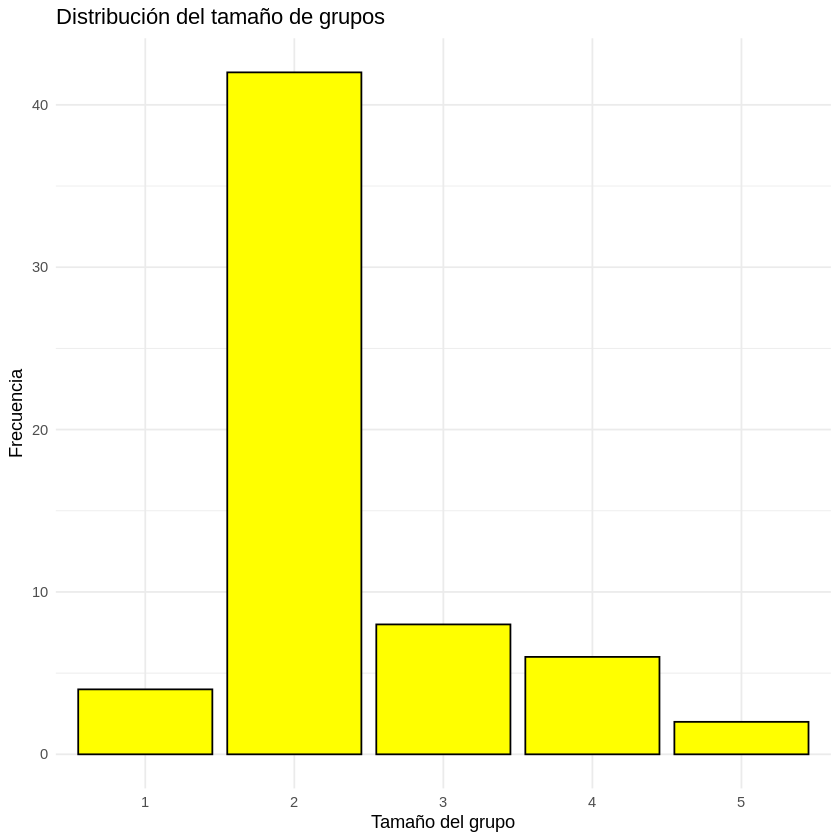

In [53]:
# Gráfico de barras para el tamaño de los grupos
ggplot(data=datos) +
  geom_bar(mapping=aes(x=factor(tamano)), color="black", fill="yellow") +
  labs(title = "Distribución del tamaño de grupos",
       x = "Tamaño del grupo",
       y = "Frecuencia") +
  theme_minimal()

In [54]:
# Convertir la columna hora (formato HH:MM)
datos <- datos %>%
  mutate(hora = as.POSIXct(hora, format = "%H:%M", tz = "UTC")) %>%
  arrange(hora) %>%
  mutate(tiempo_entre_llegadas = as.numeric(difftime(hora, lag(hora), units = "mins"))) %>%
  drop_na(tiempo_entre_llegadas)

In [55]:
datos

hora,tamano,tiempo_entre_llegadas
<dttm>,<dbl>,<dbl>
1970-01-01 08:21:00,2,11
1970-01-01 08:28:00,2,7
1970-01-01 08:56:00,2,28
1970-01-01 09:04:00,2,8
1970-01-01 09:05:00,2,1
1970-01-01 09:07:00,2,2
1970-01-01 09:13:00,3,6
1970-01-01 09:14:00,2,1
1970-01-01 09:27:00,3,13


In [56]:
# Resumen estadístico
summary(datos$tiempo_entre_llegadas)

cat("Media:", mean(datos$tiempo_entre_llegadas), "\n")
cat("Número de observaciones:", nrow(datos), "\n")
cat("Desviación estándar:", sd(datos$tiempo_entre_llegadas), "\n")

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.000   7.000   9.557  12.000  55.000 

Media: 9.557377 
Número de observaciones: 61 
Desviación estándar: 9.802252 


In [57]:
# Tenemos la sospecha de que se trata de una exponencial. Por lo tanto debemos dar un candidato para lambda o para beta.
## Recordemos que en una exponencial con parámetro lambda, tenemos E[X]=1/lambda
## Por lo tanto nos conviene proponer media empírica = 1/lambda y por lo tanto lambda = 1/media empírica

lambda = 1/mean(datos$tiempo_entre_llegadas)
n_obs = nrow(datos)

In [58]:
### el ppoints(N) genera la lista de números
### (1-0.5)/N
### (2-0.5)/N
### (3-0.5)/N
### ....
### (N-0.5)/N


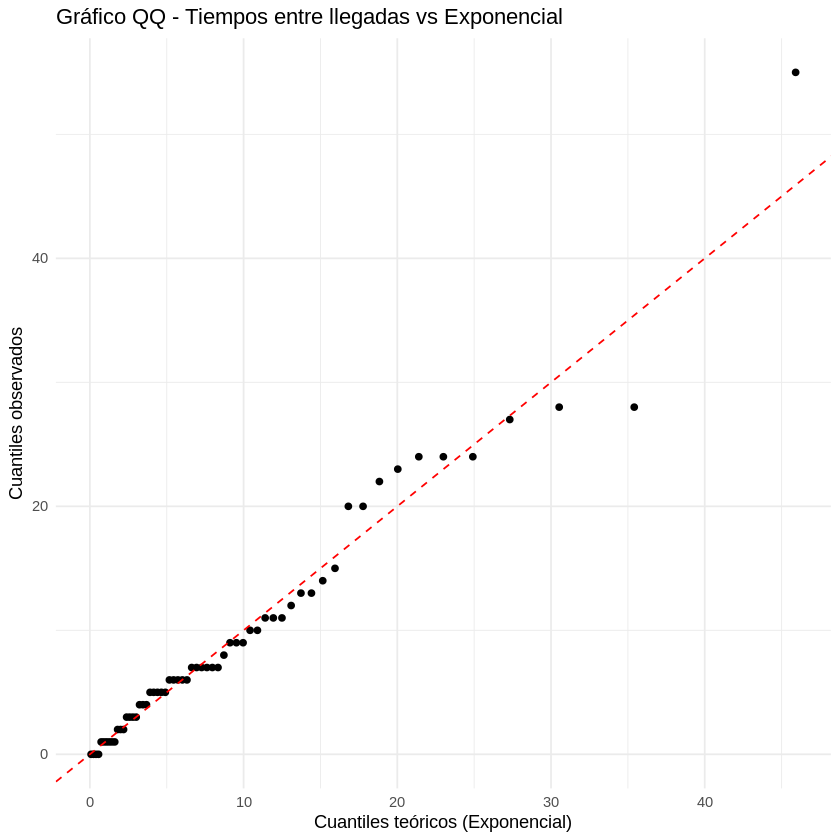

In [59]:
# ========================
# Gráfico QQ para distribución Exponencial
# ========================

# Calcular cuantiles teóricos de la exponencial
cuantiles_teoricos <- qexp(ppoints(n_obs),
                           lambda)

# Gráfico QQ
ggplot() +
  geom_point(aes(x = cuantiles_teoricos, y = sort(datos$tiempo_entre_llegadas))) +
  geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed") +
  labs(title = "Gráfico QQ - Tiempos entre llegadas vs Exponencial",
       x = "Cuantiles teóricos (Exponencial)",
       y = "Cuantiles observados") +
  theme_minimal()

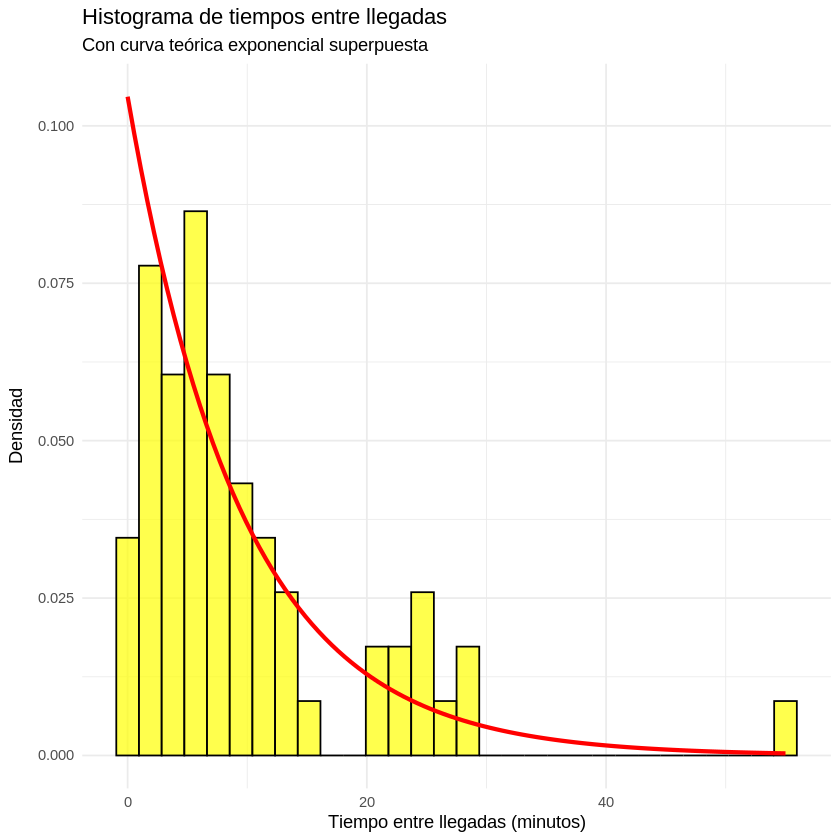

In [61]:
# Histograma de los tiempos entre llegadas
ggplot(datos, aes(x = tiempo_entre_llegadas)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30,
                 color = "black", fill = "yellow", alpha = 0.7) +
  stat_function(fun = dexp,
                args = list(rate = lambda),
                color = "red", linewidth = 1.2) +
  labs(title = "Histograma de tiempos entre llegadas",
       subtitle = "Con curva teórica exponencial superpuesta",
       x = "Tiempo entre llegadas (minutos)",
       y = "Densidad") +
  theme_minimal()

In [ ]:
mis_binomiales = rbinom(40,prob=0.3,size=50)
mis_binomiales

n_obs = length(mis_binomiales)
n_prop = 50
p_prop = mean(mis_binomiales)/50  #E[X] = np; p = E[X]/n = media empirica / n

In [ ]:
# Calcular cuantiles teóricos de la exponencial
cuantiles_teoricos <- qbinom(ppoints(n_obs),
                           size=n_prop,prob=p_prop)

# Gráfico QQ
ggplot() +
  geom_point(aes(x = cuantiles_teoricos, y = sort(mis_binomiales))) +
  geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed") +
  labs(title = "Gráfico QQ - Tiempos entre llegadas vs Exponencial",
       x = "Cuantiles teóricos (Exponencial)",
       y = "Cuantiles observados") +
  theme_minimal()